In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from IPython.display import display, Math, Latex

from IPython.display import display, Math, Latex
import ipywidgets as widgets
from matplotlib.widgets import Slider, Button

from scipy.fft import fft, ifft
import scipy.special as sp
import scipy.optimize 

In [2]:
Delta = 0 #no detuning
kappa = 300e6*2*np.pi
gamma = kappa *0.1

In [3]:
def Gain_get_DPA(kappa, lam, drive, n_levels, theta, phi):
    
    a = qt.destroy(n_levels)
        
    H_DPA = Delta * a.dag() * a + lam*np.exp(-1j*theta)/2 * a.dag() * a.dag() + np.conj(lam*np.exp(-1j*theta))/2 * a * a
    
    c_op_list = [np.sqrt(kappa) * a]
    epsilon = drive*kappa*np.exp(-1j*phi) #probe strength
    a_in = 1j * epsilon / np.sqrt(kappa)
    H_probe = epsilon * a.dag() + np.conj(epsilon) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_probe, c_op_list)
    a_exp = qt.expect(a, final_state)
    a_out = np.sqrt(kappa) * a_exp + a_in

    epsilon_2 = drive*kappa * 1j * np.exp(-1j*phi)
    a_in_2 = 1j * epsilon_2 / np.sqrt(kappa)
    H_probe = epsilon_2 * a.dag() + np.conj(epsilon_2) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_probe, c_op_list)
    a_exp_2 = qt.expect(a, final_state)
    a_out_2 = np.sqrt(kappa) * a_exp_2 + a_in_2
    
    def Gain_DPA_matrix(a_out, a_in, a_out_2, a_in_2):
        X_out = a_out + np.conj(a_out)
        X_out = X_out / np.sqrt(2)
        P_out = - a_out + np.conj(a_out)
        P_out = 1j * P_out / np.sqrt(2)
        X_in = a_in + np.conj(a_in)
        X_in = X_in / np.sqrt(2)
        P_in = - a_in + np.conj(a_in)
        P_in = 1j * P_in / np.sqrt(2)

        X_out_2 = a_out_2 + np.conj(a_out_2)
        X_out_2 = X_out_2 / np.sqrt(2)
        P_out_2 = - a_out_2 + np.conj(a_out_2)
        P_out_2 = 1j * P_out_2 / np.sqrt(2)
        X_in_2 = a_in_2 + np.conj(a_in_2)
        X_in_2 = X_in_2 / np.sqrt(2)
        P_in_2 = - a_in_2 + np.conj(a_in_2)
        P_in_2 = 1j * P_in_2 / np.sqrt(2)

        IN = np.array([[X_in,X_in_2],[P_in,P_in_2]])
        OUT = np.array([[X_out,X_out_2],[P_out,P_out_2]])
        Matrix = OUT @ np.linalg.inv(IN)
        # print(IN @ np.linalg.inv(IN))
        return Matrix

    g_DPA = Gain_DPA_matrix(a_out,a_in,a_out_2,a_in_2)
    Gain_DPA = 1/4 * np.abs(g_DPA[0,0] + g_DPA[1,1] + 1j*(g_DPA[1,0] - g_DPA[0,1]))**2
        
    return g_DPA,Gain_DPA

In [4]:
def Gain_get_lossy_DPA(kappa, gamma, lam, drive, n_levels, theta, phi):
    
    a = qt.destroy(n_levels)
        
    H_DPA = Delta * a.dag() * a + lam*np.exp(-1j*theta)/2 * a.dag() * a.dag() + np.conj(lam*np.exp(-1j*theta))/2 * a * a
    
    c_op_list = [np.sqrt(kappa+gamma) * a]
    epsilon = drive*kappa*np.exp(-1j*phi) #probe strength
    a_in = 1j * epsilon / np.sqrt(kappa)
    H_probe = epsilon * a.dag() + np.conj(epsilon) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_probe, c_op_list)
    a_exp = qt.expect(a, final_state)
    a_out = np.sqrt(kappa) * a_exp + a_in

    epsilon_2 = drive*kappa * 1j * np.exp(-1j*phi)
    a_in_2 = 1j * epsilon_2 / np.sqrt(kappa)
    H_probe = epsilon_2 * a.dag() + np.conj(epsilon_2) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_probe, c_op_list)
    a_exp_2 = qt.expect(a, final_state)
    a_out_2 = np.sqrt(kappa) * a_exp_2 + a_in_2
    
    def Gain_DPA_matrix(a_out, a_in, a_out_2, a_in_2):
        X_out = a_out + np.conj(a_out)
        X_out = X_out / np.sqrt(2)
        P_out = - a_out + np.conj(a_out)
        P_out = 1j * P_out / np.sqrt(2)
        X_in = a_in + np.conj(a_in)
        X_in = X_in / np.sqrt(2)
        P_in = - a_in + np.conj(a_in)
        P_in = 1j * P_in / np.sqrt(2)

        X_out_2 = a_out_2 + np.conj(a_out_2)
        X_out_2 = X_out_2 / np.sqrt(2)
        P_out_2 = - a_out_2 + np.conj(a_out_2)
        P_out_2 = 1j * P_out_2 / np.sqrt(2)
        X_in_2 = a_in_2 + np.conj(a_in_2)
        X_in_2 = X_in_2 / np.sqrt(2)
        P_in_2 = - a_in_2 + np.conj(a_in_2)
        P_in_2 = 1j * P_in_2 / np.sqrt(2)

        IN = np.array([[X_in,X_in_2],[P_in,P_in_2]])
        OUT = np.array([[X_out,X_out_2],[P_out,P_out_2]])
        Matrix = OUT @ np.linalg.inv(IN)
        # print(IN @ np.linalg.inv(IN))
        return Matrix
    kg = kappa + gamma
    g_DPA = Gain_DPA_matrix(a_out,a_in,a_out_2,a_in_2)
    Gain_DPA = 1/4 * np.abs(g_DPA[0,0] + g_DPA[1,1] + 1j*(g_DPA[1,0] - g_DPA[0,1]))**2
    Gain_DPA_analytical = np.abs(((kappa*kg/2-1j*kappa*Delta) / (Delta**2+(kg/2)**2-lam**2))-1)**2 #assumed w=0 here (ws-wp/2)
        
    return g_DPA,Gain_DPA,Gain_DPA_analytical

In [8]:
def Gain_get_JPA(kappa, gamma, lam, LAM, drive, n_levels, theta, phi):
    
    a = qt.destroy(n_levels)
    
    H_DPA = Delta * a.dag() * a + lam*np.exp(-1j*theta)/2 * a.dag() * a.dag() + np.conj(lam*np.exp(-1j*theta))/2 * a * a
    H_alpha = LAM * a.dag() * a.dag() * a * a  - (LAM/150) *(a.dag()*a.dag()*a.dag()*a + a.dag() * a * a * a)
  
    c_op_list = [np.sqrt(kappa+gamma) * a]

    epsilon = drive*kappa*np.exp(-1j*phi)
    a_in = 1j * epsilon / np.sqrt(kappa)
    H_probe = epsilon * a.dag() + np.conj(epsilon) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)
    a_exp = qt.expect(a, final_state)
    a_out = np.sqrt(kappa) * a_exp + a_in

    epsilon_2 = drive*kappa * 1j*np.exp(-1j*phi)
    a_in_2 = 1j * epsilon_2 / np.sqrt(kappa)
    H_probe = epsilon_2 * a.dag() + np.conj(epsilon_2) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)
    a_exp_2 = qt.expect(a, final_state)
    a_out_2 = np.sqrt(kappa) * a_exp_2 + a_in_2
    
    def Gain_JPA_matrix(a_out, a_in, a_out_2, a_in_2):
        X_out = a_out + np.conj(a_out)
        X_out = X_out / np.sqrt(2)
        P_out = - a_out + np.conj(a_out)
        P_out = 1j * P_out / np.sqrt(2)
        X_in = a_in + np.conj(a_in)
        X_in = X_in / np.sqrt(2)
        P_in = - a_in + np.conj(a_in)
        P_in = 1j * P_in / np.sqrt(2)

        X_out_2 = a_out_2 + np.conj(a_out_2)
        X_out_2 = X_out_2 / np.sqrt(2)
        P_out_2 = - a_out_2 + np.conj(a_out_2)
        P_out_2 = 1j * P_out_2 / np.sqrt(2)
        X_in_2 = a_in_2 + np.conj(a_in_2)
        X_in_2 = X_in_2 / np.sqrt(2)
        P_in_2 = - a_in_2 + np.conj(a_in_2)
        P_in_2 = 1j * P_in_2 / np.sqrt(2)

        IN = np.array([[X_in,X_in_2],[P_in,P_in_2]])
        OUT = np.array([[X_out,X_out_2],[P_out,P_out_2]])
        Matrix = OUT @ np.linalg.inv(IN)
        # print(IN @ np.linalg.inv(IN))
        return Matrix
    g_JPA = Gain_JPA_matrix(a_out,a_in,a_out_2,a_in_2)
    Gain_JPA = 1/4 * np.abs(g_JPA[0,0] + g_JPA[1,1] + 1j*(g_JPA[1,0] - g_JPA[0,1]))**2
    
    #delta_tilde = Delta + 4*Lam*n
    #gsw_JPA_theory = 
    #Gain_JPA_theory = np.abs(gsw_JPA_theory)**2
    
    return g_JPA,Gain_JPA

In [9]:
def Gain_get_KFJPA(kappa,gamma,lam, LAM, drive, n_levels, theta, phi):
        
    a = qt.destroy(n_levels) 
    
    eta = -LAM/(50*np.sqrt(2))
    
    H_DPA = Delta * a.dag() * a + lam*np.exp(-1j*theta)/2 * a.dag()*a.dag() + lam*np.exp(1j*theta)/2 * a * a
   
    c_op_list = [np.sqrt(kappa+gamma) * a]

    epsilon = drive*kappa*np.exp(-1j*phi)
    a_in = 1j * epsilon / np.sqrt(kappa)
    H_alpha =  eta/3 * (a.dag()*a.dag()*a.dag()*a + a.dag() * a * a * a) #+ eta/2*(a.dag()*a.dag() + a * a)
    H_probe = epsilon * a.dag() + np.conj(epsilon) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)
    a_exp = qt.expect(a, final_state)
    a_out = np.sqrt(kappa) * a_exp + a_in

    epsilon_2 = drive*kappa * 1j*np.exp(-1j*phi)
    a_in_2 = 1j * epsilon_2 / np.sqrt(kappa)
    H_probe = epsilon_2 * a.dag() + np.conj(epsilon_2) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)
    a_exp_2 = qt.expect(a, final_state)
    a_out_2 = np.sqrt(kappa) * a_exp_2 + a_in_2
    
    
    def Gain_matrix(a_out, a_in, a_out_2, a_in_2):
        X_out = a_out + np.conj(a_out)
        X_out = X_out / np.sqrt(2)
        P_out = - a_out + np.conj(a_out)
        P_out = 1j * P_out / np.sqrt(2)
        X_in = a_in + np.conj(a_in)
        X_in = X_in / np.sqrt(2)
        P_in = - a_in + np.conj(a_in)
        P_in = 1j * P_in / np.sqrt(2)

        X_out_2 = a_out_2 + np.conj(a_out_2)
        X_out_2 = X_out_2 / np.sqrt(2)
        P_out_2 = - a_out_2 + np.conj(a_out_2)
        P_out_2 = 1j * P_out_2 / np.sqrt(2)
        X_in_2 = a_in_2 + np.conj(a_in_2)
        X_in_2 = X_in_2 / np.sqrt(2)
        P_in_2 = - a_in_2 + np.conj(a_in_2)
        P_in_2 = 1j * P_in_2 / np.sqrt(2)

        IN = np.array([[X_in,X_in_2],[P_in,P_in_2]])
        OUT = np.array([[X_out,X_out_2],[P_out,P_out_2]])
        Matrix = OUT @ np.linalg.inv(IN)
        # print(IN @ np.linalg.inv(IN))
        return Matrix
    g_KFJPA = Gain_matrix(a_out,a_in,a_out_2,a_in_2)
    Gain_KFJPA = 1/4 * np.abs(g_KFJPA[0,0] + g_KFJPA[1,1] + 1j*(g_KFJPA[1,0] - g_KFJPA[0,1]))**2

    return g_KFJPA,Gain_KFJPA

# Compare lossless DPA with lossy DPA

In [10]:
step = 30

In [102]:
drive = 0.2
n_levels = 150

In [103]:
# lossless DPA
g_DPA11=np.zeros(step, dtype=np.complex128)
g_DPA12=np.zeros(step, dtype=np.complex128)
g_DPA21=np.zeros(step, dtype=np.complex128)
g_DPA22=np.zeros(step, dtype=np.complex128)
Gain_DPA=np.zeros(step, dtype=np.complex128)

In [106]:
i = 0

for lam in np.linspace(0.0,1.94,step)*kappa/4:
    c_Q,d_Q,e_Q = Gain_get_lossy_DPA(kappa, 0,lam, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g_DPA11[i]=c_Q[0,0]
    g_DPA12[i]=c_Q[0,1]
    g_DPA21[i]=c_Q[1,0]
    g_DPA22[i]=c_Q[1,1]
    Gain_DPA[i]=d_Q
    i+=1

In [107]:
# lossy DPA 0.1 kappa
gl_DPA11=np.zeros(step, dtype=np.complex128)
gl_DPA12=np.zeros(step, dtype=np.complex128)
gl_DPA21=np.zeros(step, dtype=np.complex128)
gl_DPA22=np.zeros(step, dtype=np.complex128)
Gainl_DPA=np.zeros(step, dtype=np.complex128)
Gainl_DPA_an=np.zeros(step, dtype=np.complex128) #analytical

In [108]:
i = 0
for lam in np.linspace(0.0,1.94,step)*kappa/4:
    cl_Q,dl_Q,el_Q = Gain_get_lossy_DPA(kappa,gamma,lam, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    gl_DPA11[i]=cl_Q[0,0]
    gl_DPA12[i]=cl_Q[0,1]
    gl_DPA21[i]=cl_Q[1,0]
    gl_DPA22[i]=cl_Q[1,1]
    Gainl_DPA[i]=dl_Q
    Gainl_DPA_an[i]=el_Q
    i+=1

In [109]:
# lossy DPA 0.3 kappa
g2_DPA11=np.zeros(step, dtype=np.complex128)
g2_DPA12=np.zeros(step, dtype=np.complex128)
g2_DPA21=np.zeros(step, dtype=np.complex128)
g2_DPA22=np.zeros(step, dtype=np.complex128)
Gain2_DPA=np.zeros(step, dtype=np.complex128)
Gain2_DPA_an=np.zeros(step, dtype=np.complex128) #analytical

In [110]:
i = 0
for lam in np.linspace(0.0,1.94,step)*kappa/4:
    c2_Q,d2_Q,e2_Q = Gain_get_lossy_DPA(kappa,0.3*kappa,lam, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g2_DPA11[i]=c2_Q[0,0]
    g2_DPA12[i]=c2_Q[0,1]
    g2_DPA21[i]=c2_Q[1,0]
    g2_DPA22[i]=c2_Q[1,1]
    Gain2_DPA[i]=d2_Q
    Gain2_DPA_an[i]=e2_Q
    i+=1

In [111]:
# lossy DPA 0.5 kappa
g3_DPA11=np.zeros(step, dtype=np.complex128)
g3_DPA12=np.zeros(step, dtype=np.complex128)
g3_DPA21=np.zeros(step, dtype=np.complex128)
g3_DPA22=np.zeros(step, dtype=np.complex128)
Gain3_DPA=np.zeros(step, dtype=np.complex128)
Gain3_DPA_an=np.zeros(step, dtype=np.complex128) #analytical

In [112]:
i = 0
for lam in np.linspace(0.0,1.94,step)*kappa/4:
    c3_Q,d3_Q,e3_Q = Gain_get_lossy_DPA(kappa,0.5*kappa,lam, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g3_DPA11[i]=c3_Q[0,0]
    g3_DPA12[i]=c3_Q[0,1]
    g3_DPA21[i]=c3_Q[1,0]
    g3_DPA22[i]=c3_Q[1,1]
    Gain3_DPA[i]=d3_Q
    Gain3_DPA_an[i]=e3_Q
    i+=1

In [113]:
list_x = np.linspace(0.0,1.94,30)*kappa/4

C:\Users\kagan\anaconda3\envs\kerrcat\lib\site-packages\matplotlib\collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


(-10.0, 28.0)

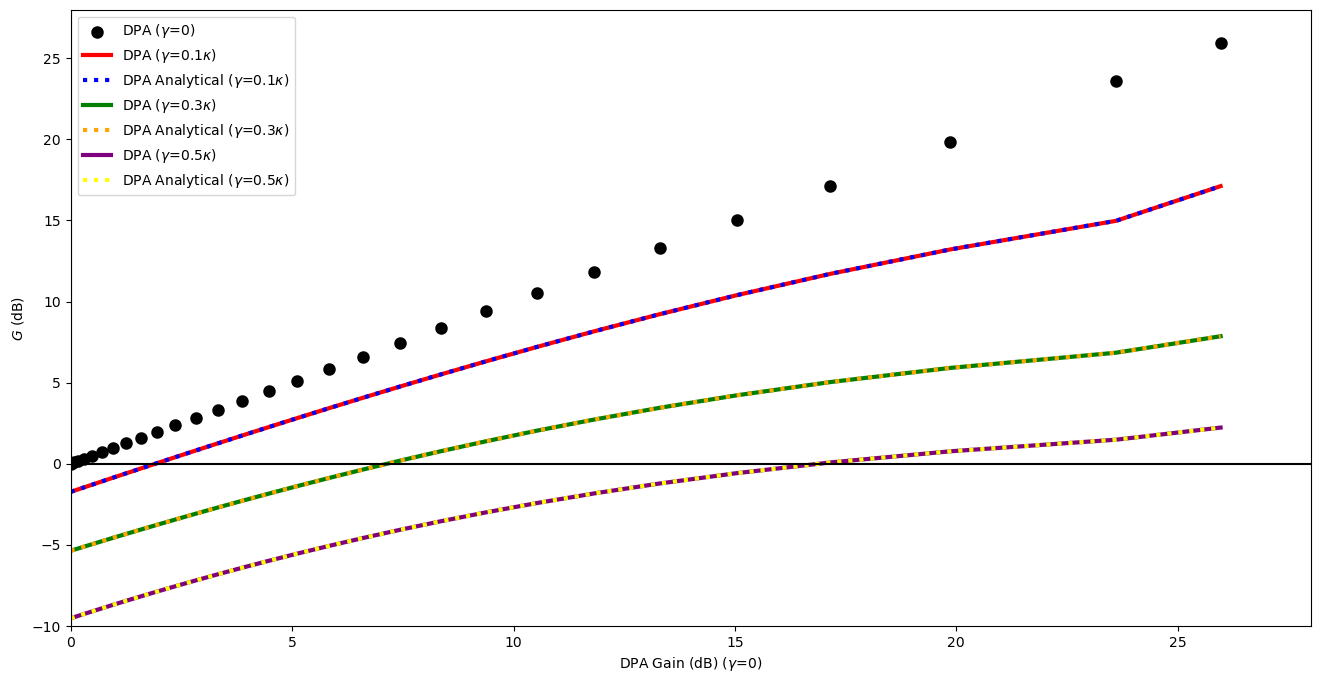

In [115]:
plt.figure(figsize=(16,8))
plt.scatter(10*np.log10(Gain_DPA), 10*np.log10(Gain_DPA), c='black', linewidth=3, label = 'DPA ($\gamma$=0)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainl_DPA), c='red', linewidth=3, label = 'DPA ($\gamma$=0.1$\kappa$)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainl_DPA_an), linewidth=3, c='blue',linestyle='dotted', label = 'DPA Analytical ($\gamma$=0.1$\kappa$)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain2_DPA), c='green', linewidth=3, label = 'DPA ($\gamma$=0.3$\kappa$)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain2_DPA_an), linewidth=3, c='orange',linestyle='dotted', label = 'DPA Analytical ($\gamma$=0.3$\kappa$)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain3_DPA), c='purple', linewidth=3, label = 'DPA ($\gamma$=0.5$\kappa$)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain3_DPA_an), linewidth=3, c='yellow',linestyle='dotted', label = 'DPA Analytical ($\gamma$=0.5$\kappa$)')

plt.axvline(x=0)
thresh = [0 for i in enumerate(10*np.log10(Gain_DPA))]
plt.plot(list_x, thresh, c='black')



plt.legend()
plt.xlabel('DPA Gain (dB) ($\gamma$=0)')
plt.ylabel('$G$ (dB)')
plt.xlim(0,28)
plt.ylim(-10,28)

# Check for how much drive G=1 (=0dB) for lossy DPA 

(0.0, 609468974.7964197)

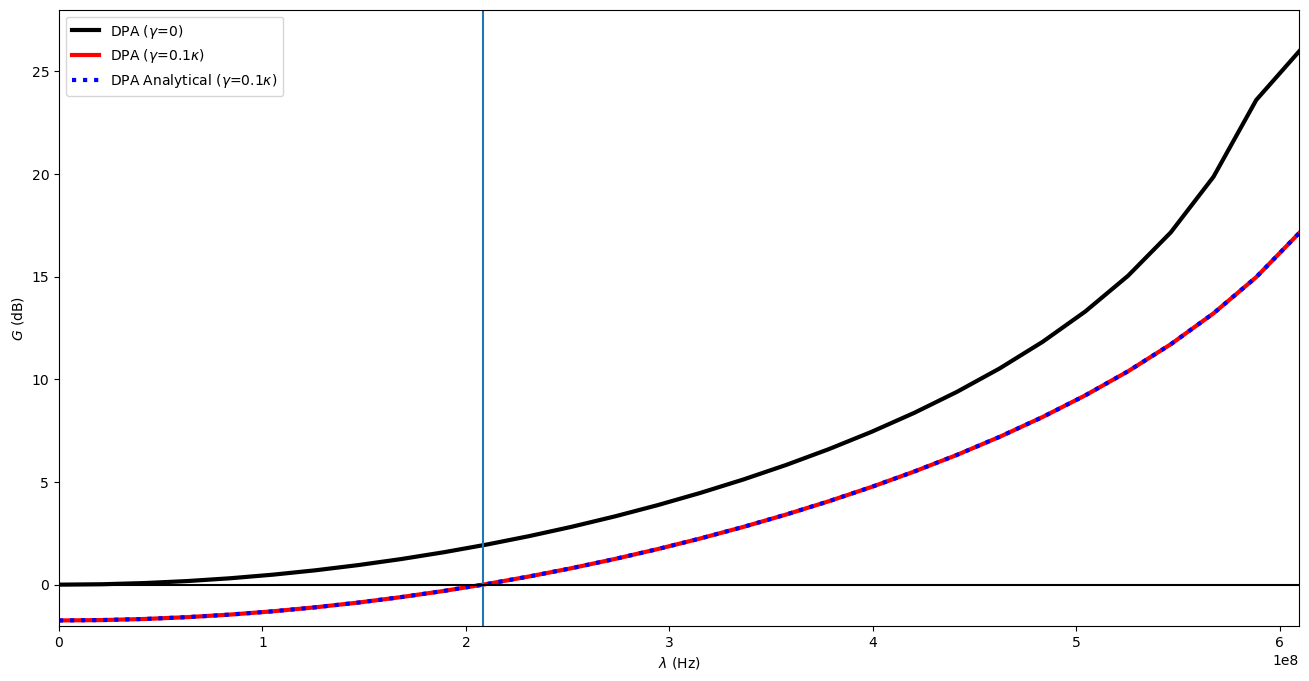

In [116]:
plt.figure(figsize=(16,8))
plt.plot(np.linspace(0.0,1.94,30)*kappa/4, 10*np.log10(Gain_DPA), c='black', linewidth=3, label = 'DPA ($\gamma$=0)')
plt.plot(np.linspace(0.0,1.94,30)*kappa/4, 10*np.log10(Gainl_DPA), c='red', linewidth=3, label = 'DPA ($\gamma$=0.1$\kappa$)')
plt.plot(np.linspace(0.0,1.94,30)*kappa/4, 10*np.log10(Gainl_DPA_an), linewidth=3, c='blue',linestyle='dotted', label = 'DPA Analytical ($\gamma$=0.1$\kappa$)')

plt.axvline(x=0.5*np.sqrt((kappa+gamma)*gamma))
list_x = np.linspace(0.0,1.94,30)*kappa/4
thresh = [0 for i in enumerate(list_x)]
plt.plot(list_x, thresh, c='black')

plt.legend()
plt.xlabel('$\lambda$ (Hz)')
plt.ylabel('$G$ (dB)')
plt.ylim(-2,28)
plt.xlim(0,list_x.max())

# The vertical line is drawn based on analytical expression |$\lambda$|=0.5*Sqrt($(\kappa+\gamma)\gamma$)

# Compare JPA with lossy JPA ($\Lambda=-10^{-2}\kappa$) 

In [23]:
# lossless 
# JPA with LAM=-1e-2*kappa
g_JPA11=[]
g_JPA12=[]
g_JPA21=[]
g_JPA22=[]
Gain_JPA=[]

# lossy 
# JPA with LAM=-1e-2*kappa , gamma = 0.1 kappa
gl_JPA11=[]
gl_JPA12=[]
gl_JPA21=[]
gl_JPA22=[]
Gainl_JPA=[]

# lossy 
# JPA with LAM=-1e-2*kappa , gamma = 0.3 kappa
g2_JPA11=[]
g2_JPA12=[]
g2_JPA21=[]
g2_JPA22=[]
Gain2_JPA=[]


# lossy 
# JPA with LAM=-1e-2*kappa , gamma = 0.5 kappa
g3_JPA11=[]
g3_JPA12=[]
g3_JPA21=[]
g3_JPA22=[]
Gain3_JPA=[]



# Vary the pumping strength, n_levels and df
drive = 0.2
n_levels = 250
for lam in np.linspace(0.0,1.94,30)*kappa/4:
    
    f_Q,g_Q = Gain_get_JPA(kappa,0,lam,-1e-2*kappa, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g_JPA11.append(f_Q[0,0])
    g_JPA12.append(f_Q[0,1])
    g_JPA21.append(f_Q[1,0])
    g_JPA22.append(f_Q[1,1])
    Gain_JPA.append(g_Q)
    
    fl_Q,gl_Q = Gain_get_JPA(kappa,gamma,lam,-1e-2*kappa, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    gl_JPA11.append(fl_Q[0,0])
    gl_JPA12.append(fl_Q[0,1])
    gl_JPA21.append(fl_Q[1,0])
    gl_JPA22.append(fl_Q[1,1])
    Gainl_JPA.append(gl_Q)
    
    f2_Q,g2_Q = Gain_get_JPA(kappa,0.3 * kappa,lam,-1e-2*kappa, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g2_JPA11.append(f2_Q[0,0])
    g2_JPA12.append(f2_Q[0,1])
    g2_JPA21.append(f2_Q[1,0])
    g2_JPA22.append(f2_Q[1,1])
    Gain2_JPA.append(g2_Q)
    
    f3_Q,g3_Q = Gain_get_JPA(kappa,0.5*kappa,lam,-1e-2*kappa, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g3_JPA11.append(f3_Q[0,0])
    g3_JPA12.append(f3_Q[0,1])
    g3_JPA21.append(f3_Q[1,0])
    g3_JPA22.append(f3_Q[1,1])
    Gain3_JPA.append(g3_Q)
    
    

(-10.0, 28.0)

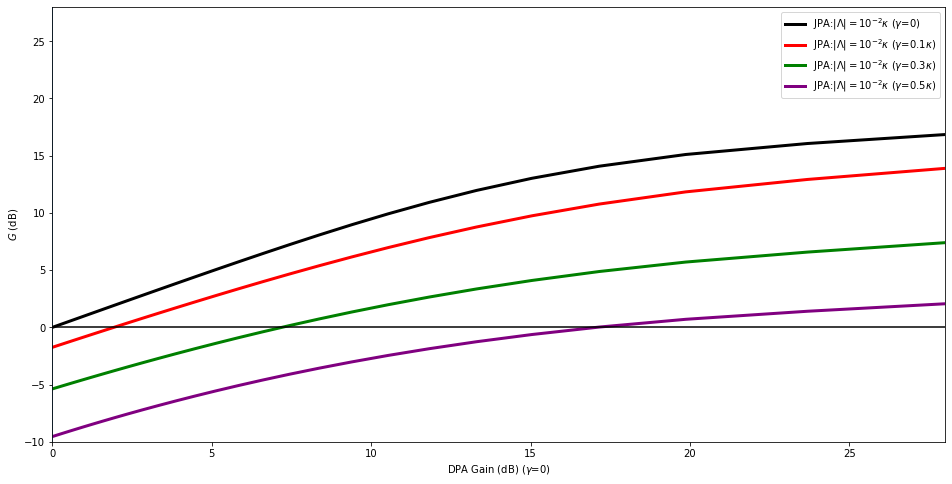

In [24]:
plt.figure(figsize=(16,8))
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_JPA), c='black', linewidth=3, label = 'JPA:$|\Lambda|=10^{-2}\kappa$ ($\gamma$=0)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainl_JPA), c='red', linewidth=3, label = 'JPA:$|\Lambda|=10^{-2}\kappa$ ($\gamma$=0.1$\kappa$)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain2_JPA), c='green', linewidth=3, label = 'JPA:$|\Lambda|=10^{-2}\kappa$ ($\gamma$=0.3$\kappa$)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain3_JPA), c='purple', linewidth=3, label = 'JPA:$|\Lambda|=10^{-2}\kappa$ ($\gamma$=0.5$\kappa$)')

plt.axvline(x=0)
thresh = [0 for i in enumerate(10*np.log10(Gain_DPA))]
plt.plot(list_x, thresh, c='black')

plt.legend()
plt.xlabel('DPA Gain (dB) ($\gamma$=0)')
plt.ylabel('$G$ (dB)')
plt.xlim(0,28)
plt.ylim(-10,28)

# Compare lossless KFJPA with lossy KFJPA 

In [15]:
# lossless 
# KFJPA
g_KFJPA11=[]
g_KFJPA12=[]
g_KFJPA21=[]
g_KFJPA22=[]
Gain_KFJPA=[]

# lossy 
# KFJPA gamma 0.1 kappa
gl_KFJPA11=[]
gl_KFJPA12=[]
gl_KFJPA21=[]
gl_KFJPA22=[]
Gainl_KFJPA=[]

# lossy 
# KFJPA gamma 0.3 kappa
g2_KFJPA11=[]
g2_KFJPA12=[]
g2_KFJPA21=[]
g2_KFJPA22=[]
Gain2_KFJPA=[]

# lossy 
# KFJPA gamma 0.5 kappa
g3_KFJPA11=[]
g3_KFJPA12=[]
g3_KFJPA21=[]
g3_KFJPA22=[]
Gain3_KFJPA=[]



# Vary the pumping strength, n_levels and df
drive = 0.2
n_levels = 250
for lam in np.linspace(0.0,1.94,30)*kappa/4:
    
    
    v_Q,w_Q = Gain_get_KFJPA(kappa,0,lam,-1e-2*kappa, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g_KFJPA11.append(v_Q[0,0])
    g_KFJPA12.append(v_Q[0,1])
    g_KFJPA21.append(v_Q[1,0])
    g_KFJPA22.append(v_Q[1,1])
    Gain_KFJPA.append(w_Q)
    
    vl_Q,wl_Q = Gain_get_KFJPA(kappa,0.03*kappa,lam,-1e-2*kappa, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    gl_KFJPA11.append(vl_Q[0,0])
    gl_KFJPA12.append(vl_Q[0,1])
    gl_KFJPA21.append(vl_Q[1,0])
    gl_KFJPA22.append(vl_Q[1,1])
    Gainl_KFJPA.append(wl_Q)
    
    v2_Q,w2_Q = Gain_get_KFJPA(kappa,0.05*kappa,lam,-1e-2*kappa, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g2_KFJPA11.append(v2_Q[0,0])
    g2_KFJPA12.append(v2_Q[0,1])
    g2_KFJPA21.append(v2_Q[1,0])
    g2_KFJPA22.append(v2_Q[1,1])
    Gain2_KFJPA.append(w2_Q)
    
    v3_Q,w3_Q = Gain_get_KFJPA(kappa,0.1*kappa,lam,-1e-2*kappa, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g3_KFJPA11.append(v3_Q[0,0])
    g3_KFJPA12.append(v3_Q[0,1])
    g3_KFJPA21.append(v3_Q[1,0])
    g3_KFJPA22.append(v3_Q[1,1])
    Gain3_KFJPA.append(w3_Q)
    
    

In [16]:
# Lossy
# KFJPA gamma 0.1 kappa
g4_KFJPA11=[]
g4_KFJPA12=[]
g4_KFJPA21=[]
g4_KFJPA22=[]
Gain4_KFJPA=[]


# Vary the pumping strength, n_levels and df
drive = 0.2
n_levels = 250
for lam in np.linspace(0.0,1.94,30)*kappa/4:
    
    
    v4_Q,w4_Q = Gain_get_KFJPA(kappa,0.3*kappa,lam,-1e-2*kappa, drive = drive, n_levels = n_levels, theta=np.pi/2, phi=0)
    g4_KFJPA11.append(v4_Q[0,0])
    g4_KFJPA12.append(v4_Q[0,1])
    g4_KFJPA21.append(v4_Q[1,0])
    g4_KFJPA22.append(v4_Q[1,1])
    Gain4_KFJPA.append(w4_Q)

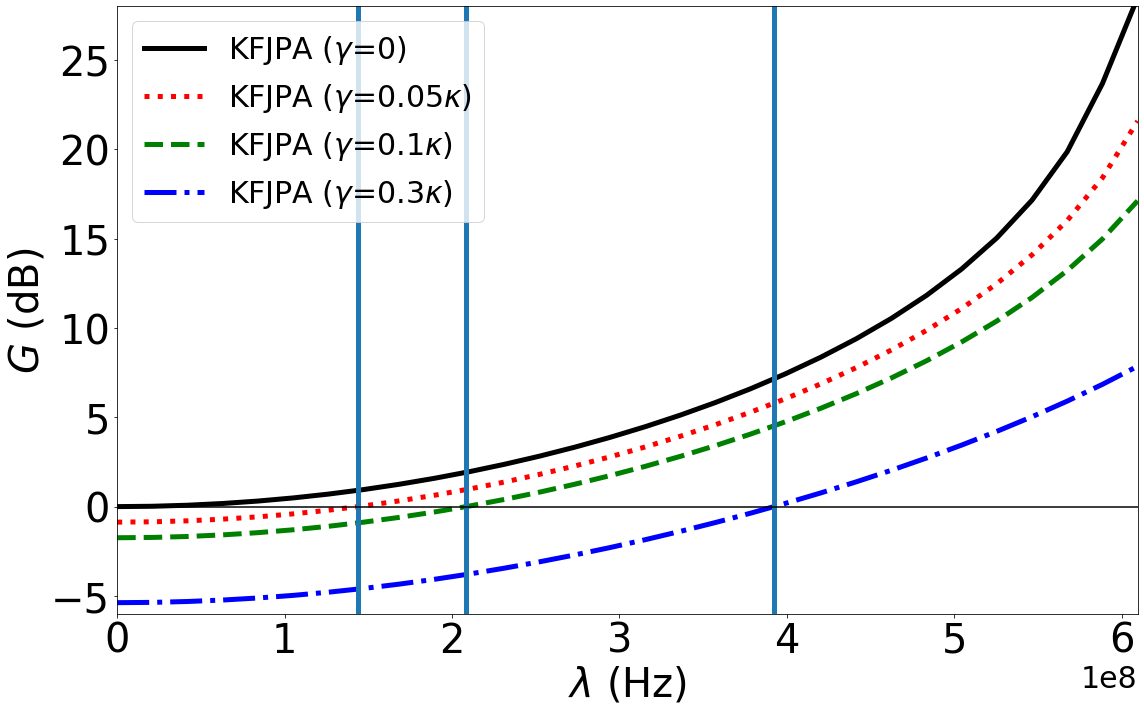

In [29]:
list_x = np.linspace(0.0,1.94,30)*kappa/4

plt.figure(figsize=(16,10))
plt.plot(list_x, 10*np.log10(Gain_KFJPA), c='black', linewidth=5, label = 'KFJPA ($\gamma$=0)')
#plt.plot(list_x, 10*np.log10(Gainl_KFJPA), c='red', linestyle='dotted', linewidth=5, label = 'KFJPA ($\gamma$=0.03$\kappa$)')
plt.plot(list_x, 10*np.log10(Gain2_KFJPA), c='red', linestyle='dotted', linewidth=5, label = 'KFJPA ($\gamma$=0.05$\kappa$)')
plt.plot(list_x, 10*np.log10(Gain3_KFJPA), c='green', linestyle='dashed', linewidth=5, label = 'KFJPA ($\gamma$=0.1$\kappa$)')
plt.plot(list_x, 10*np.log10(Gain4_KFJPA), c='blue', linestyle='-.', linewidth=5, label = 'KFJPA ($\gamma$=0.3$\kappa$)')

gamma2 = 0.05*kappa
gamma3 = 0.03*kappa
gamma4 = 0.3*kappa
plt.axvline(x=0.5*np.sqrt((kappa+gamma)*gamma),linewidth=5)
plt.axvline(x=0.5*np.sqrt((kappa+gamma2)*gamma2),linewidth=5)
plt.axvline(x=0.5*np.sqrt((kappa+gamma4)*gamma4),linewidth=5)
#plt.axvline(x=0.5*np.sqrt((kappa+gamma3)*gamma3))
thresh = [0 for i in enumerate(list_x)]
plt.plot(list_x, thresh, c='black')

plt.gca().xaxis.get_offset_text().set_size(30)


plt.legend(loc='upper left', fontsize=30)
plt.xlabel('$\lambda$ (Hz)',fontsize=40)
plt.ylabel('$G$ (dB)',fontsize=40)
plt.ylim(-6,28)
plt.xlim(0,list_x.max())
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.tight_layout()
plt.savefig("Deamp drivesies.jpeg")

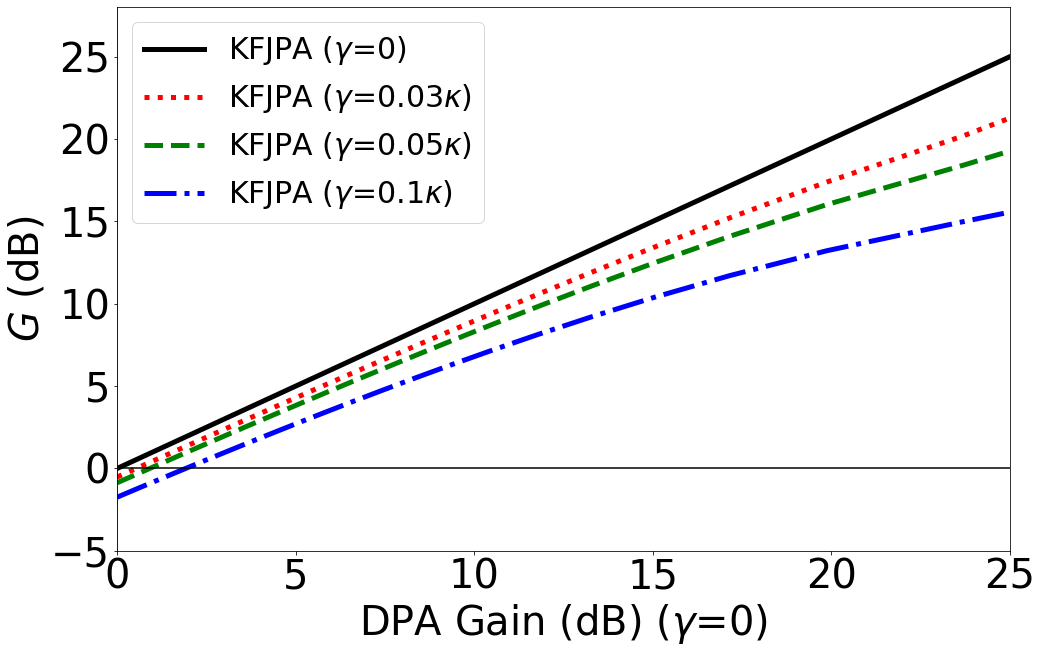

In [32]:
plt.figure(figsize=(16,10))
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_KFJPA), c='black', linewidth=5, label = 'KFJPA ($\gamma$=0)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainl_KFJPA), c='red', linestyle='dotted', linewidth=5, label = 'KFJPA ($\gamma$=0.03$\kappa$)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain2_KFJPA), c='green', linestyle='dashed', linewidth=5, label = 'KFJPA ($\gamma$=0.05$\kappa$)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain3_KFJPA), c='blue', linestyle='-.', linewidth=5, label = 'KFJPA ($\gamma$=0.1$\kappa$)')

plt.axvline(x=0)
thresh = [0 for i in enumerate(10*np.log10(Gain_DPA))]
plt.plot(list_x, thresh, c='black')

plt.legend(loc='upper left', fontsize=30)
plt.xlabel('DPA Gain (dB) ($\gamma$=0)',fontsize=40)
plt.ylabel('$G$ (dB)',fontsize=40)
plt.xlim(0,25)
plt.ylim(-5,28)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.savefig("Extra noise.jpeg")

(-2.0, 28.0)

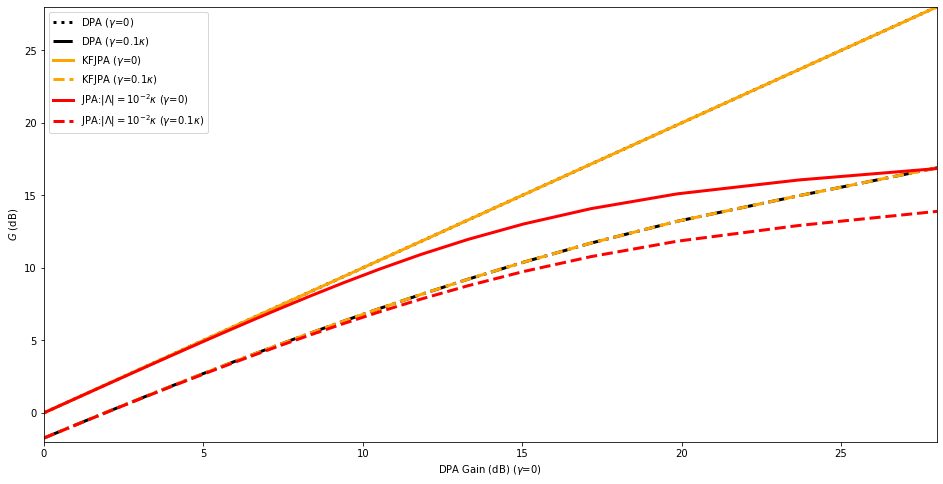

In [15]:
plt.figure(figsize=(16,8))
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_DPA), c='black', linestyle='dotted', linewidth=3, label = 'DPA ($\gamma$=0)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainl_DPA), c='black', linestyle='dashdot', linewidth=3, label = 'DPA ($\gamma$=0.1$\kappa$)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_KFJPA), c='orange', linewidth=3, label = 'KFJPA ($\gamma$=0)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainl_KFJPA), c='orange', linestyle='--', linewidth=3, label = 'KFJPA ($\gamma$=0.1$\kappa$)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_JPA), c='red', linewidth=3, label = 'JPA:$|\Lambda|=10^{-2}\kappa$ ($\gamma$=0)')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gainl_JPA), c='red', linestyle='--', linewidth=3, label = 'JPA:$|\Lambda|=10^{-2}\kappa$ ($\gamma$=0.1$\kappa$)')


plt.legend()
plt.xlabel('DPA Gain (dB) ($\gamma$=0)')
plt.ylabel('$G$ (dB)')
plt.xlim(0,28)
plt.ylim(-2,28)